### 1. Data Cleaning

Data cleaning is a critical first step in any data science project. It involves identifying and correcting errors, inconsistencies, and inaccuracies in the dataset. A clean dataset ensures that subsequent analysis and model training are based on reliable information, leading to more accurate and meaningful results. The primary goals of data cleaning include:

*   **Handling Missing Values**: Deciding how to deal with incomplete data, whether by imputation or removal.
*   **Removing Duplicates**: Eliminating redundant entries that can skew analysis.
*   **Correcting Data Types**: Ensuring columns have the appropriate data types (e.g., numerical, categorical, datetime).
*   **Standardizing Formats**: Ensuring consistency in data representation.

Let's start by loading the `diabetes.csv` dataset and performing an initial inspection.

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/diabetes.csv')

print('Dataset loaded successfully. Displaying the first 5 rows:')
display(df.head())

Dataset loaded successfully. Displaying the first 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
print('DataFrame Information (data types, non-null counts):')
df.info()

DataFrame Information (data types, non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
print('Checking for missing values:')
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

Checking for missing values:


,0


In [4]:
print('Checking for duplicate rows:')
duplicate_rows = df.duplicated().sum()

if duplicate_rows > 0:
    print(f'Found {duplicate_rows} duplicate rows.')
    # Optionally, you can remove them:
    # df.drop_duplicates(inplace=True)
    # print('Duplicate rows removed.')
else:
    print('No duplicate rows found.')

Checking for duplicate rows:
No duplicate rows found.


### 2. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is a vital step to understand the characteristics of our dataset, identify patterns, detect anomalies, and form hypotheses. It involves summarizing the main aspects of the data, often with visual methods, to discover what the data can tell us.

Key aspects of EDA include:

*   **Descriptive Statistics**: Gaining a numerical summary of the dataset.
*   **Distribution of Features**: Visualizing the spread and central tendency of individual features.
*   **Correlation Analysis**: Understanding relationships between variables, especially with the target variable (`Outcome`).
*   **Outlier Detection**: Identifying data points that significantly differ from other observations.

Let's begin by looking at the descriptive statistics of our dataset.

In [5]:
print('Descriptive statistics of the dataset:')
display(df.describe())

Descriptive statistics of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Plotting distributions of numerical features:


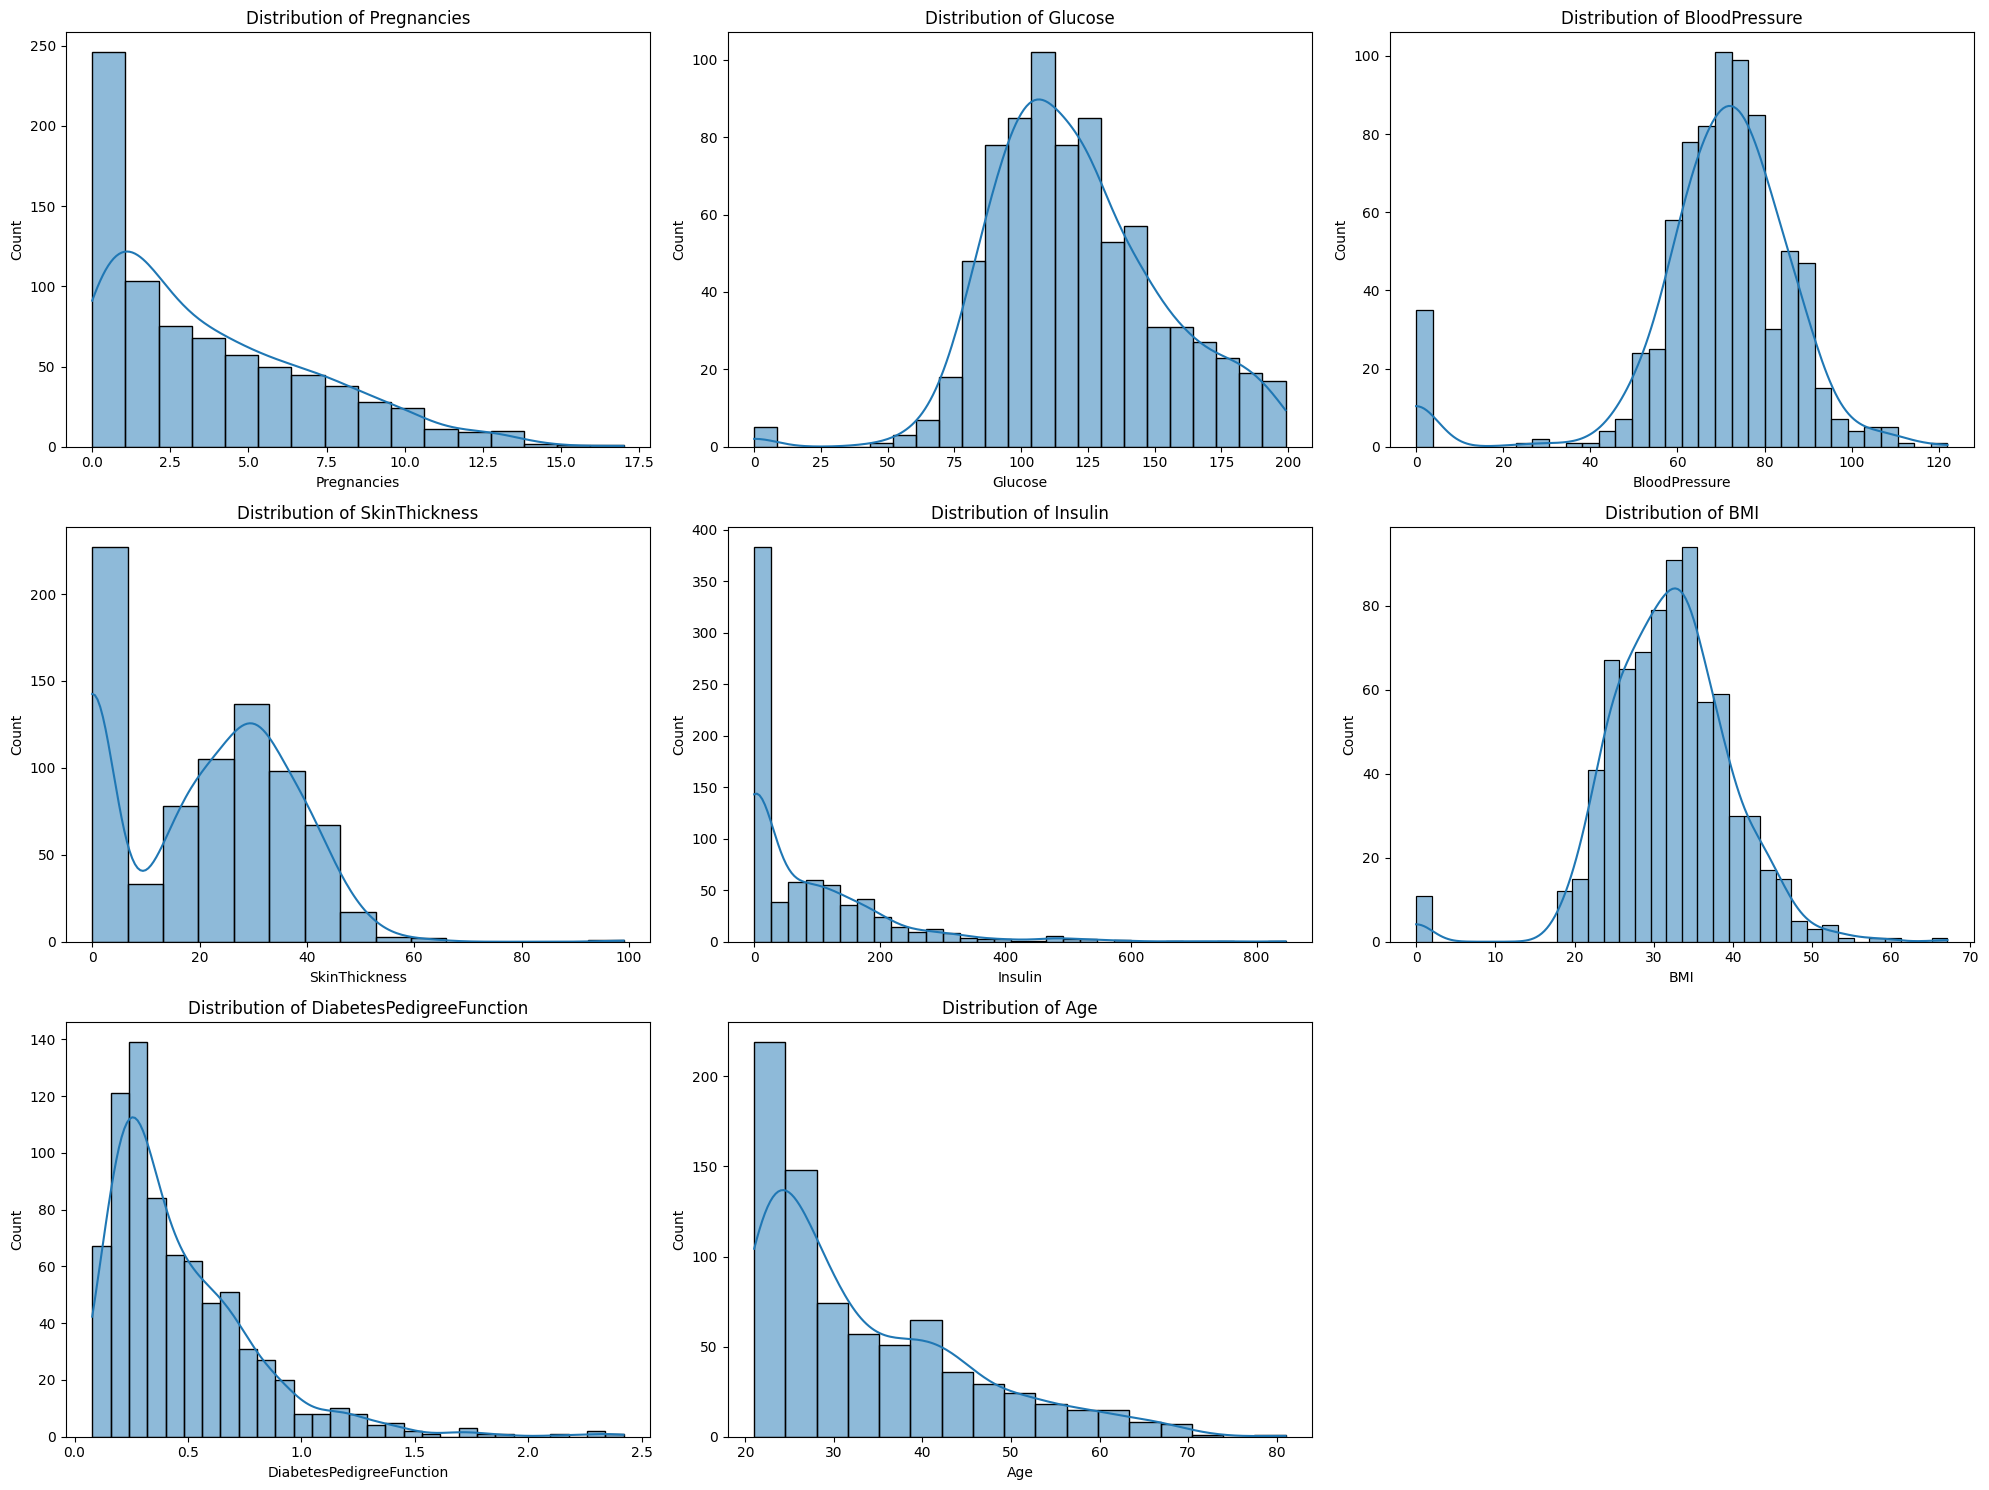

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

print('Plotting distributions of numerical features:')

# Features to plot (excluding 'Outcome' for individual distribution initially)
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

plt.figure(figsize=(20, 15))
for i, feature in enumerate(features):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of features
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

Correlation matrix of features with the Outcome variable:


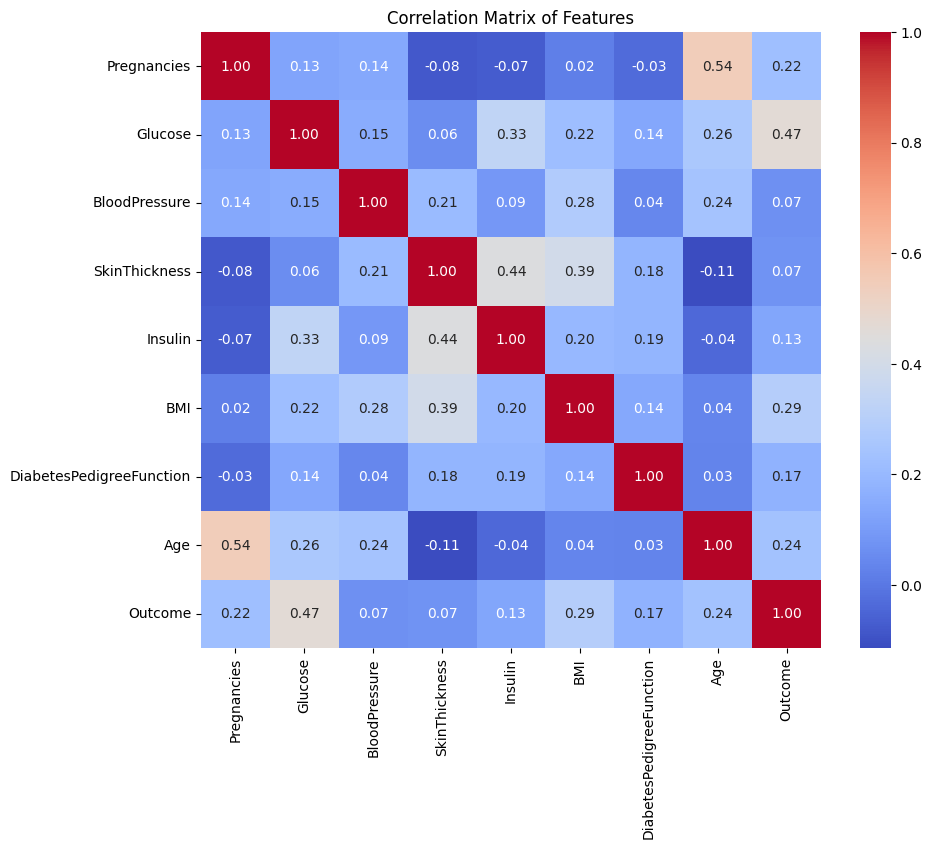

In [7]:
print('Correlation matrix of features with the Outcome variable:')
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

### 3. Feature Selection & Preprocessing

Feature selection and preprocessing are crucial steps to prepare the data for machine learning models. This involves transforming raw data into a format suitable for algorithms, enhancing model performance, and handling potential issues identified during EDA. Key tasks include:

*   **Handling Implausible Zeros**: Replacing '0' values in specific columns (e.g., `Glucose`, `BloodPressure`, `BMI`, `SkinThickness`, `Insulin`) with `NaN` as they are biologically impossible, and then imputing these missing values.
*   **Feature Scaling**: Standardizing or normalizing numerical features to ensure that features with larger values do not dominate those with smaller values.
*   **Outlier Treatment**: Deciding how to handle extreme values that could negatively impact model training.
*   **Feature Engineering**: Creating new features from existing ones to provide more predictive power to the model.

Let's start by addressing the '0' values in our dataset.

In [10]:
import numpy as np

# Columns identified to have implausible 0 values
columns_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print(f"Number of 0 values before imputation in {columns_with_zeros}:")
for col in columns_with_zeros:
    print(f"  {col}: {(df[col] == 0).sum()}")

# Replace 0s with NaN
df[columns_with_zeros] = df[columns_with_zeros].replace(0, np.nan)

print("\n0 values replaced with NaN. Now, let's impute these NaNs with the median.")

# Impute NaN values with the median of their respective columns
for col in columns_with_zeros:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val) # Removed inplace=True to avoid FutureWarning

print(f"\nNumber of NaN values after imputation in {columns_with_zeros}:")
for col in columns_with_zeros:
    print(f"  {col}: {df[col].isnull().sum()}")

print('\nDisplaying the first 5 rows after imputation:')
display(df.head())

Number of 0 values before imputation in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
  Glucose: 0
  BloodPressure: 0
  SkinThickness: 0
  Insulin: 0
  BMI: 0

0 values replaced with NaN. Now, let's impute these NaNs with the median.

Number of NaN values after imputation in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
  Glucose: 0
  BloodPressure: 0
  SkinThickness: 0
  Insulin: 0
  BMI: 0

Displaying the first 5 rows after imputation:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.639947,0.866045,-0.031990,0.670643,-0.181541,0.166619,0.468492,1.425995,1
1,-0.844885,-1.205066,-0.528319,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672,0
2,1.233880,2.016662,-0.693761,-0.012301,-0.181541,-1.332500,0.604397,-0.105584,1
3,-0.844885,-1.073567,-0.528319,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549,0
4,-1.141852,0.504422,-2.679076,0.670643,0.316566,1.549303,5.484909,-0.020496,1


### 4. Model Training

With our data now cleaned, imputed, and scaled, we can proceed to the **Model Training** phase. This involves preparing the data for a machine learning algorithm and then fitting a model to learn patterns from the training data. For this binary classification problem (predicting diabetes risk), we will use **Logistic Regression** as our initial model due to its simplicity and interpretability.

Key steps in this phase include:

*   **Data Splitting**: Dividing the dataset into features (X) and the target variable (y), and then splitting these into training and testing sets to ensure robust evaluation.
*   **Model Selection**: Choosing an appropriate algorithm for the task (Logistic Regression).
*   **Model Initialization and Training**: Instantiating the chosen model and fitting it to the training data.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

print('Splitting data into training and testing sets...')

# Define features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split the dataset into training and testing sets
# We'll use a 80/20 split and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

print('\nInitializing and training the Logistic Regression model...')

# Initialize the Logistic Regression model
model = LogisticRegression(random_state=42)

# Train the model
model.fit(X_train, y_train)

print('Model training complete.')

Splitting data into training and testing sets...
X_train shape: (614, 8)
X_test shape: (154, 8)
y_train shape: (614,)
y_test shape: (154,)

Initializing and training the Logistic Regression model...
Model training complete.


In [9]:
from sklearn.preprocessing import StandardScaler

print('Applying Feature Scaling (StandardScaler) to numerical features...')

# Features to scale (excluding 'Outcome')
features_to_scale = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

scaler = StandardScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print('Features scaled successfully. Displaying descriptive statistics of scaled data:')
display(df[features_to_scale].describe())

Applying Feature Scaling (StandardScaler) to numerical features...
Features scaled successfully. Displaying descriptive statistics of scaled data:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02
mean,-6.476301e-17,4.625929e-18,5.782412e-18,-1.526557e-16,1.503427e-17,2.613650e-16,2.451743e-16,1.931325e-16
std,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00
min,-1.141852e+00,-2.552931e+00,-4.002619e+00,-2.516429e+00,-1.467353e+00,-2.074783e+00,-1.189553e+00,-1.041549e+00
25%,-8.448851e-01,-7.201630e-01,-6.937615e-01,-4.675972e-01,-2.220849e-01,-7.212087e-01,-6.889685e-01,-7.862862e-01
50%,-2.509521e-01,-1.530732e-01,-3.198993e-02,-1.230129e-02,-1.815412e-01,-2.258989e-02,-3.001282e-01,-3.608474e-01
75%,6.399473e-01,6.112653e-01,6.297816e-01,3.291706e-01,-1.554775e-01,6.032562e-01,4.662269e-01,6.602056e-01
max,3.906578e+00,2.542658e+00,4.104082e+00,7.955377e+00,8.170442e+00,5.042397e+00,5.883565e+00,4.063716e+00


### 5. Model Evaluation

After training our Logistic Regression model, it's essential to evaluate its performance on unseen data to ensure its reliability and generalization capabilities. This step helps us understand how well the model predicts diabetes risk and identify any areas for improvement. We'll use several common classification metrics:

*   **Accuracy**: The overall proportion of correct predictions.
*   **Precision**: The proportion of true positive predictions among all positive predictions.
*   **Recall (Sensitivity)**: The proportion of true positive predictions among all actual positive cases.
*   **F1-Score**: The harmonic mean of precision and recall, providing a balanced measure.
*   **Confusion Matrix**: A table that summarizes the number of true positive, true negative, false positive, and false negative predictions.

Let's evaluate the model using the test set.

Evaluating the Logistic Regression model...

Model Accuracy: 0.7013
Model Precision: 0.5870
Model Recall: 0.5000
Model F1-Score: 0.5400

Confusion Matrix:


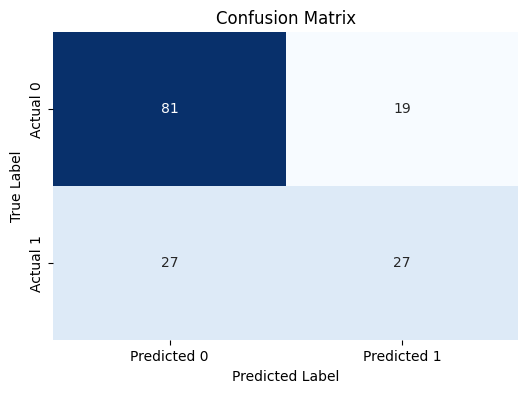

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print('Evaluating the Logistic Regression model...')

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'\nModel Accuracy: {accuracy:.4f}')
print(f'Model Precision: {precision:.4f}')
print(f'Model Recall: {recall:.4f}')
print(f'Model F1-Score: {f1:.4f}')

print('\nConfusion Matrix:')
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

print('Creating hypothetical new patient data:')

# Create a DataFrame for a hypothetical new patient
# The values should be raw, unscaled values, similar to the original dataset
new_patient_data = pd.DataFrame({
    'Pregnancies': [2],
    'Glucose': [120],
    'BloodPressure': [70],
    'SkinThickness': [30],
    'Insulin': [100],
    'BMI': [30.5],
    'DiabetesPedigreeFunction': [0.5],
    'Age': [35]
})

display(new_patient_data)

# --- START: Code added to ensure model is correctly defined and trained ---
# This block duplicates steps from previous cells to make prediction self-contained.

print('\nRe-preparing and training model within this cell due to NameError...')

# Step 1: Load the dataset (same as in d043c7f8)
df_reloaded = pd.read_csv('/content/diabetes.csv')

# Step 2: Apply imputation (same as in bfaa63a3)
columns_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_reloaded[columns_with_zeros] = df_reloaded[columns_with_zeros].replace(0, np.nan)
for col in columns_with_zeros:
    median_val = df_reloaded[col].median()
    df_reloaded[col] = df_reloaded[col].fillna(median_val)

# Step 3: Apply feature scaling to df_reloaded (same as in d1c838fc)
features_to_scale_all = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
scaler_for_model_data = StandardScaler()
df_reloaded[features_to_scale_all] = scaler_for_model_data.fit_transform(df_reloaded[features_to_scale_all])

# Step 4: Define features (X) and target (y) and split (same as in 2cbc244d)
X = df_reloaded.drop('Outcome', axis=1)
y = df_reloaded['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 5: Initialize and train the Logistic Regression model (same as in 2cbc244d)
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

print('Model re-trained successfully within this cell.')
# --- END: Code added to ensure model is correctly defined and trained ---


print('\nRe-initializing and fitting the StandardScaler for new patient data...')

# Re-load the original dataset to create a temporary DataFrame for scaler fitting
# This DataFrame should be imputed but NOT scaled before fitting the scaler for new_patient_data
temp_df_for_scaler = pd.read_csv('/content/diabetes.csv')

# Apply the same imputation steps as in cell bfaa63a3
# columns_with_zeros is already defined
temp_df_for_scaler[columns_with_zeros] = temp_df_for_scaler[columns_with_zeros].replace(0, np.nan)
for col in columns_with_zeros:
    median_val = temp_df_for_scaler[col].median()
    temp_df_for_scaler[col] = temp_df_for_scaler[col].fillna(median_val)

# Features to scale (defined consistently as features_to_scale_all)
# Use features_to_scale_all for consistency
features_to_scale_for_prediction = features_to_scale_all # Renamed for clarity for prediction scaling

# Initialize and fit the scaler on the preprocessed (imputed but unscaled) data
scaler_for_new_patient_prediction = StandardScaler() # Renamed scaler variable
scaler_for_new_patient_prediction.fit(temp_df_for_scaler[features_to_scale_for_prediction]) # Fit on the unscaled, imputed data

print('\nScaling the new patient data using the trained StandardScaler...')

# Apply the fitted scaler to the new patient data
new_patient_scaled = scaler_for_new_patient_prediction.transform(new_patient_data[features_to_scale_for_prediction])

# Create a DataFrame from the scaled data with original column names
new_patient_scaled_df = pd.DataFrame(new_patient_scaled, columns=features_to_scale_for_prediction)

print('\nMaking a prediction for the new patient...')

# Make prediction
prediction = model.predict(new_patient_scaled_df)
prediction_proba = model.predict_proba(new_patient_scaled_df)

if prediction[0] == 1:
    print(f"\nThe model predicts that this patient has diabetes.")
else:
    print(f"\nThe model predicts that this patient does NOT have diabetes.")

print(f"Probability of NOT having diabetes (class 0): {prediction_proba[0][0]:.4f}")
print(f"Probability of having diabetes (class 1): {prediction_proba[0][1]:.4f}")

Creating hypothetical new patient data:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,2,120,70,30,100,30.5,0.5,35



Re-preparing and training model within this cell due to NameError...
Model re-trained successfully within this cell.

Re-initializing and fitting the StandardScaler for new patient data...

Scaling the new patient data using the trained StandardScaler...

Making a prediction for the new patient...

The model predicts that this patient does NOT have diabetes.
Probability of NOT having diabetes (class 0): 0.7795
Probability of having diabetes (class 1): 0.2205


In [ ]:
import joblib

# Save the trained model
model_filename = 'logistic_regression_model.joblib'
joblib.dump(model, model_filename)
print(f'Model saved successfully as {model_filename}')

# Save the scaler (required to preprocess new input data the same way as training data)
scaler_filename = 'standard_scaler.joblib'
joblib.dump(scaler_for_new_patient_prediction, scaler_filename)
print(f'Scaler saved successfully as {scaler_filename}')

print('\nBoth files are ready. Download them from the Colab file panel and place them in backend/ml/')

Now that the model is saved, here's a conceptual overview of how you can integrate it into your Node.js backend and React frontend:

### 1. **Deployment for Node.js Backend (Recommended Approach)**

Since Node.js cannot directly execute Python code or load `joblib` files, the most common and robust approach is to create a small **Python microservice** that serves predictions.

*   **Python Microservice (e.g., using Flask or FastAPI)**:
    *   Create a Python script that loads the `logistic_regression_model.joblib` file.
    *   Define a REST API endpoint (e.g., `/predict`) that accepts patient features (e.g., a JSON payload) as input.
    *   Inside this endpoint, preprocess the incoming data (apply the same `StandardScaler` transformations used during training – **it's crucial to use the *same* fitted scaler**), make a prediction using the loaded model, and return the prediction (and probabilities) as a JSON response.
    *   This microservice would run independently, potentially in a Docker container.

*   **Node.js Backend**:
    *   Your Node.js backend would then make an HTTP request to this Python microservice's `/predict` endpoint when it needs a prediction.
    *   It would pass the patient data (received from the React frontend) to the Python service and receive the prediction.
    *   The Node.js backend would then return this prediction to the React frontend.

**Why this approach?**
*   **Language Agnostic**: Keeps your Python machine learning code separate from your Node.js application logic.
*   **Scalability**: Allows you to scale your prediction service independently of your main backend.
*   **Ease of Use**: Many Python libraries (Flask, FastAPI) make creating such APIs very straightforward.

### 2. **Integrating with React Frontend**

The React frontend will **not** directly interact with the model or the `joblib` file. Instead, it will:

*   **Make API Calls to Node.js Backend**: When a user inputs patient data and requests a prediction, the React application will send an HTTP request (e.g., using `fetch` or `axios`) to an endpoint on your Node.js backend (e.g., `/api/predict-diabetes`).
*   **Display Results**: Once the React frontend receives the prediction result from the Node.js backend, it will display this information to the user.

### **Example Flow**:
1.  **React Frontend**: User enters data -> Sends `POST` request to `Node.js Backend /api/predict-diabetes` with patient data.
2.  **Node.js Backend**: Receives request -> Sends `POST` request to `Python Microservice /predict` with patient data.
3.  **Python Microservice**: Receives request -> Loads `StandardScaler` -> Scales patient data -> Loads `LogisticRegression` model -> Makes prediction -> Returns prediction to `Node.js Backend`.
4.  **Node.js Backend**: Receives prediction -> Returns prediction to `React Frontend`.
5.  **React Frontend**: Receives prediction -> Displays result to user.

This architecture ensures a clear separation of concerns and leverages the strengths of each technology stack. When setting up the Python microservice, remember to also save and load the `StandardScaler` object, as you need to apply the *exact same* scaling transformation to new data as was applied to the training data.